In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.join(os.getcwd(), "../fortran"))
from cletkf_wloc import common_da as cda
#from wrf import getvar, to_np, ALL_TIMES, dbz
# Load the cross-section data
data = np.load("../data/cross_sections/ensemble_cross_sections3_2023-12-16_19:00:00.npz")
#data = np.load("/home/jorge.gacitua/datosdemerzel/CrossSection_Assimilation/ensemble_cross_sections.npz")
cross_sections = data["cross_sections"]


# Get relevant dimensions
nx, ny, nz, nbv, nvar = cross_sections.shape  # (lon, lat, levels, members, variables)
print("cross_sections shape:", cross_sections.shape)
dbz_idx = 0#nvar - 1  # If DBZ is the last variable

dbz_data_all = np.zeros((nx,nz,nbv))

for i in range(nx):
    for j in range(nz):
        for k in range(nbv):
            qg = cross_sections[i, 0, j, k, 0]
            qr = cross_sections[i, 0, j, k, 1]
            qs = cross_sections[i, 0, j, k, 2]
            tt = cross_sections[i, 0, j, k, 3]
            pp = cross_sections[i, 0, j, k, 4]*100.0  # convert hPa to Pa
            dbz_data_all[i,j,k] = cda.calc_ref( qr , qs , qg , tt , pp )
  

cross_sections shape: (77, 1, 43, 30, 8)


In [12]:
print(np.min(cross_sections[:,:,:,:,0]))
print(np.max(cross_sections[:,:,:,:,0]))

print(np.min(cross_sections[:,:,:,:,1]))
print(np.nanmax(cross_sections[:,:,:,:,1]))

print(np.nanmin(cross_sections[:,:,:,:,2]))
print(np.nanmax(cross_sections[:,:,:,:,2]))

print(np.nanmin(cross_sections[:,:,:,:,3]))
print(np.nanmax(cross_sections[:,:,:,:,3]))

print(np.nanmin(cross_sections[:,:,:,:,4]))
print(np.nanmax(cross_sections[:,:,:,:,4]))

0.0
0.013217579
0.0
0.010273602
0.0
0.004640885
186.88419
302.96863
11.631656
925.31006


In [11]:
np.isnan(dbz_data_all).any()

False

<ipython-input-9-30733ebe9c72>:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 0.98])


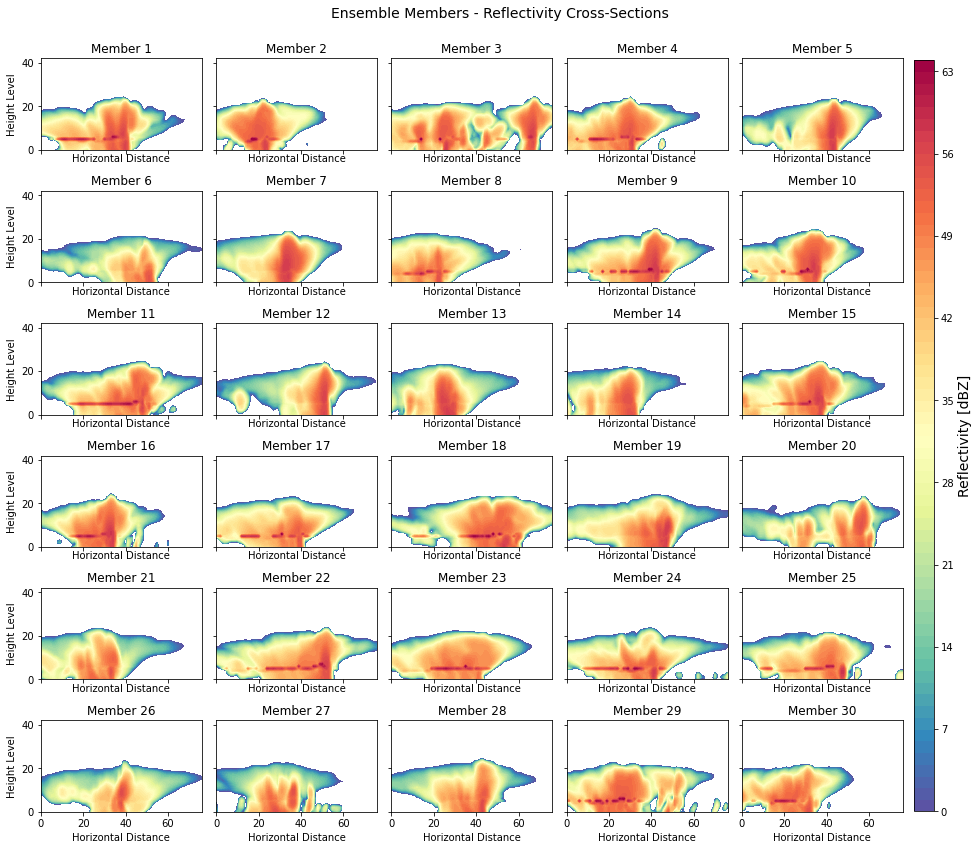

In [9]:
fig, axs = plt.subplots(6, 5, figsize=(14, 12), sharex=True, sharey=True)
axs = axs.flatten()

for i in range(nbv):
    ax = axs[i]
    label = f"Member {i+1}"

    levels = np.arange(0,65,1.)

 
    #cm = ax.pcolormesh(dbz_data_all[:, :, i].T, cmap="Spectral_r")
    cm = ax.contourf(dbz_data_all[:, :, i].T, cmap="Spectral_r", levels=levels)
    ax.set_title(label)
    ax.set_xlabel("Horizontal Distance")
    if i % 5 == 0:
        ax.set_ylabel("Height Level")

cbar_axis = fig.add_axes([0.91, 0.049, 0.02, 0.87])  # [left, bottom, width, height]
cbar = fig.colorbar(cm, cax=cbar_axis, orientation="vertical", label="Reflectivity [dBZ]")
cbar.set_label("Reflectivity [dBZ]", fontsize=14)
plt.suptitle("Ensemble Members - Reflectivity Cross-Sections", fontsize=14)

plt.tight_layout(rect=[0, 0, 0.91, 0.98])
plt.show()


In [10]:
np.max(dbz_data_all[:,:,0])

62.16955113027802